# Modelo Elo-Poisson Dinâmico

Implementação do modelo de *Stochastic Gradient Ascent* sobre a log-verossimilhança de Poisson, conforme derivado no documento teórico. As taxas esperadas de gols são:

$$\lambda_A = \exp(\alpha_A - \beta_B), \quad \lambda_B = \exp(\alpha_B - \beta_A)$$

A regra de atualização após cada partida com placar $(x, y)$ é um passo de SGD **ponderado** pelo peso $w$ da competição:

$$\alpha_A \mathrel{+}= \eta \cdot w \cdot (x - \lambda_A), \quad \beta_A \mathrel{-}= \eta \cdot w \cdot (y - \lambda_B)$$
$$\alpha_B \mathrel{+}= \eta \cdot w \cdot (y - \lambda_B), \quad \beta_B \mathrel{-}= \eta \cdot w \cdot (x - \lambda_A)$$

Os pesos $w$ seguem a mesma escala de importância usada nos modelos Bayesianos do projeto (Copa do Mundo = 6, amistoso = 1). Todos os parâmetros iniciam em zero — prior neutro de 1 gol esperado por time. O período de treinamento é controlado pela variável `START_DATE`.

In [1]:
import sys

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import poisson as sp_poisson

from src.constants import GROUPS
from src.data import prepare_cycle_data

## 1. Carregamento e preparação dos dados

`START_DATE` define o início do período de treinamento. A função `prepare_cycle_data` aplica o mesmo filtro de volume mínimo de partidas usado nos modelos Bayesianos e calcula a coluna `game_weight` — peso de cada partida baseado na importância da competição.

In [2]:
START_DATE = "2019-01-01"

df, teams, team_map = prepare_cycle_data(
    "../data/results.csv",
    start_date=START_DATE,
    apply_decay=False,
)

df = df.sort_values("date").reset_index(drop=True)

print(f"Período: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Partidas: {len(df):,}  |  Seleções: {len(teams)}")
df[
    [
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "tournament",
        "game_weight",
    ]
].head(10)

Dados preparados: 6857 jogos e 211 seleções identificadas.
Período: 2019-01-02 → 2026-06-03
Partidas: 6,857  |  Seleções: 211


,date,home_team,away_team,home_score,away_score,tournament,game_weight
0,2019-01-02,Oman,Thailand,2.0,0.0,Friendly,1.0
1,2019-01-05,United Arab Emirates,Bahrain,1.0,1.0,AFC Asian Cup,4.0
2,2019-01-06,Syria,Palestine,0.0,0.0,AFC Asian Cup,4.0
3,2019-01-06,Australia,Jordan,0.0,1.0,AFC Asian Cup,4.0
4,2019-01-06,Thailand,India,1.0,4.0,AFC Asian Cup,4.0
5,2019-01-07,Iran,Yemen,5.0,0.0,AFC Asian Cup,4.0
6,2019-01-07,China PR,Kyrgyzstan,2.0,1.0,AFC Asian Cup,4.0
7,2019-01-07,South Korea,Philippines,1.0,0.0,AFC Asian Cup,4.0
8,2019-01-08,Saudi Arabia,North Korea,4.0,0.0,AFC Asian Cup,4.0
9,2019-01-08,Finland,Sweden,1.0,0.0,Friendly,1.0


## 2. Implementação do modelo

O método `update` recebe o peso `w` da partida e escala o passo de gradiente por ele: competições mais importantes corrigem os parâmetros com maior intensidade.

O modelo suporta **learning rate variável por número de partidas**, inspirado no fator K do xadrez (FIDE):

| Fase | Partidas jogadas | η | Analogia FIDE |
|------|-----------------|---|---------------|
| Provisório | < 30 | `η₁` (4× base) | K = 40 |
| Transição | 30 – 59 | `η₂` (2× base) | K = 20 |
| Estabelecido | ≥ 60 | `η` (base) | K = 10 |

Cada seleção mantém um contador próprio de partidas e usa seu η individual.

**Por que o xadrez não precisa de clipping e o modelo de Poisson precisa:** no FIDE, a diferença de resultado `S − E` está sempre em `[−1, 1]`. Aqui, `x − λ` é ilimitado — um time estreante com λ ≈ 1 que recebe 8 gols gera um gradiente de −7, que com `η·w` alto derruba β rapidamente; na partida seguinte, λ_oponente = exp(α_opp − β_baixo) pode ser centenas, criando uma cascata. O parâmetro `grad_clip` resolve isso truncando o gradiente em `±C` antes do passo SGD, o que equivale a limitar o impacto de qualquer partida, independente do quão inesperado seja o placar.

In [3]:
class EloPoissonModel:
    """Online Elo-Poisson model via weighted SGD on the Poisson log-likelihood.

    eta_phases: list of (threshold, eta) sorted by threshold. A team with fewer
    games than threshold[i] uses eta[i]. Above all thresholds, uses self.eta.
    Example (FIDE 4:2:1): eta_phases=[(30, 0.20), (60, 0.10)], eta=0.05.

    grad_clip: if set, clamps (x - λ) to [-grad_clip, grad_clip] before the SGD
    step. Necessary when using eta_phases because (x - λ) is unbounded in Poisson
    (unlike chess where |S - E| ≤ 1), so a new team with miscalibrated λ can
    trigger a gradient cascade without clipping.
    """

    def __init__(
        self,
        teams: list[str],
        eta: float = 0.05,
        eta_phases: list[tuple[int, float]] | None = None,
        grad_clip: float | None = None,
    ):
        self.teams = teams
        self.eta = eta
        self.eta_phases = sorted(eta_phases, key=lambda x: x[0]) if eta_phases else None
        self.grad_clip = grad_clip
        self.alpha = {t: 0.0 for t in teams}
        self.beta = {t: 0.0 for t in teams}
        self.n_games = {t: 0 for t in teams}

    def _get_eta(self, team: str) -> float:
        """Learning rate for team based on how many games it has played."""
        if not self.eta_phases:
            return self.eta
        n = self.n_games[team]
        for threshold, phase_eta in self.eta_phases:
            if n < threshold:
                return phase_eta
        return self.eta

    def expected_goals(self, home: str, away: str) -> tuple[float, float]:
        lam_home = np.exp(self.alpha[home] - self.beta[away])
        lam_away = np.exp(self.alpha[away] - self.beta[home])
        return lam_home, lam_away

    def update(self, home: str, away: str, x: int, y: int, weight: float = 1.0) -> None:
        """One weighted SGD step; each team uses its own current learning rate."""
        lam_a, lam_b = self.expected_goals(home, away)
        step_a = self._get_eta(home) * weight
        step_b = self._get_eta(away) * weight
        grad_a = x - lam_a
        grad_b = y - lam_b
        if self.grad_clip is not None:
            grad_a = float(np.clip(grad_a, -self.grad_clip, self.grad_clip))
            grad_b = float(np.clip(grad_b, -self.grad_clip, self.grad_clip))
        self.alpha[home] += step_a * grad_a
        self.beta[home] -= step_a * grad_b
        self.alpha[away] += step_b * grad_b
        self.beta[away] -= step_b * grad_a
        self.n_games[home] += 1
        self.n_games[away] += 1

    def fit(self, df) -> "EloPoissonModel":
        """Train in chronological order, weighting each match by game_weight."""
        has_weight = "game_weight" in df.columns
        for row in df.itertuples(index=False):
            home, away = row.home_team, row.away_team
            if home in self.alpha and away in self.alpha:
                w = row.game_weight if has_weight else 1.0
                self.update(
                    home, away, int(row.home_score), int(row.away_score), weight=w
                )
        return self

    def parameters(self):
        return pd.DataFrame(
            {
                "team": self.teams,
                "alpha": [self.alpha[t] for t in self.teams],
                "beta": [self.beta[t] for t in self.teams],
                "n_games": [self.n_games[t] for t in self.teams],
            }
        ).set_index("team")

## 3. Treino do modelo

O modelo é treinado em ordem cronológica sobre todas as partidas do período. Cada jogo atualiza os quatro parâmetros das seleções envolvidas com intensidade proporcional ao peso da competição.

In [ ]:
# Learning rate schedule (FIDE-like 4:2:1 ratio)
# < N1 games → ETA_1  |  N1–N2 games → ETA_2  |  >= N2 games → ETA
ETA = 0.05
ETA_PHASES = [(30, 0.20), (60, 0.10)]
# grad_clip prevents the cascade: new team → β very negative → λ_opp huge →
# gradient (x − λ) huge → β overshoots positive → repeat. Clipping at 5 goals
# bounds each step while preserving sensitivity across all realistic scorelines.
GRAD_CLIP = 5.0

model = EloPoissonModel(teams, eta=ETA, eta_phases=ETA_PHASES, grad_clip=GRAD_CLIP).fit(
    df
)

params = model.parameters()
params["strength"] = params["alpha"] + params["beta"]
params = params.sort_values("strength", ascending=False)

print(
    f"Modelo treinado com η variável: fases {ETA_PHASES} → base η = {ETA}  |"
    f"  grad_clip = {GRAD_CLIP}"
)
print(f"Partidas processadas: {len(df):,}")
params.head(10)

Modelo treinado com η variável: fases [(30, 0.2), (60, 0.1)] → base η = 0.05  |  grad_clip = 5.0
Partidas processadas: 6,857


,alpha,beta,n_games,strength
team,,,,
Argentina,1.435489,2.608860,88,4.044348
Morocco,1.292926,1.636373,102,2.929299
Ecuador,0.864280,1.867105,85,2.731385
Brazil,1.623250,0.996965,85,2.620216
Colombia,1.606104,0.888413,85,2.494517
Japan,1.158373,1.207626,95,2.365999
England,1.103517,1.141291,89,2.244808
Australia,1.274228,0.954215,70,2.228444
Uruguay,0.702117,1.478335,80,2.180451


In [5]:
# Distribuição de partidas por seleção e fase final de η
def phase_label(n, phases, base_eta):
    for threshold, eta in sorted(phases, key=lambda x: x[0]):
        if n < threshold:
            return f"Provisório (η={eta})"
    return f"Estabelecido (η={base_eta})"


phase_df = params[["n_games"]].copy()
phase_df["phase"] = phase_df["n_games"].apply(lambda n: phase_label(n, ETA_PHASES, ETA))
print(phase_df["phase"].value_counts().to_string())
print(
    f"\nPartidas por seleção — min: {phase_df['n_games'].min()}, "
    f"mediana: {phase_df['n_games'].median():.0f}, "
    f"max: {phase_df['n_games'].max()}"
)

phase
Estabelecido (η=0.05)    130
Provisório (η=0.1)        64
Provisório (η=0.2)        17

Partidas por seleção — min: 18, mediana: 70, max: 121


## 4. Análise dos parâmetros

Scatter de força de ataque (α) versus solidez defensiva (β) para todas as seleções treinadas. As 48 classificadas para a Copa 2026 são destacadas em vermelho.

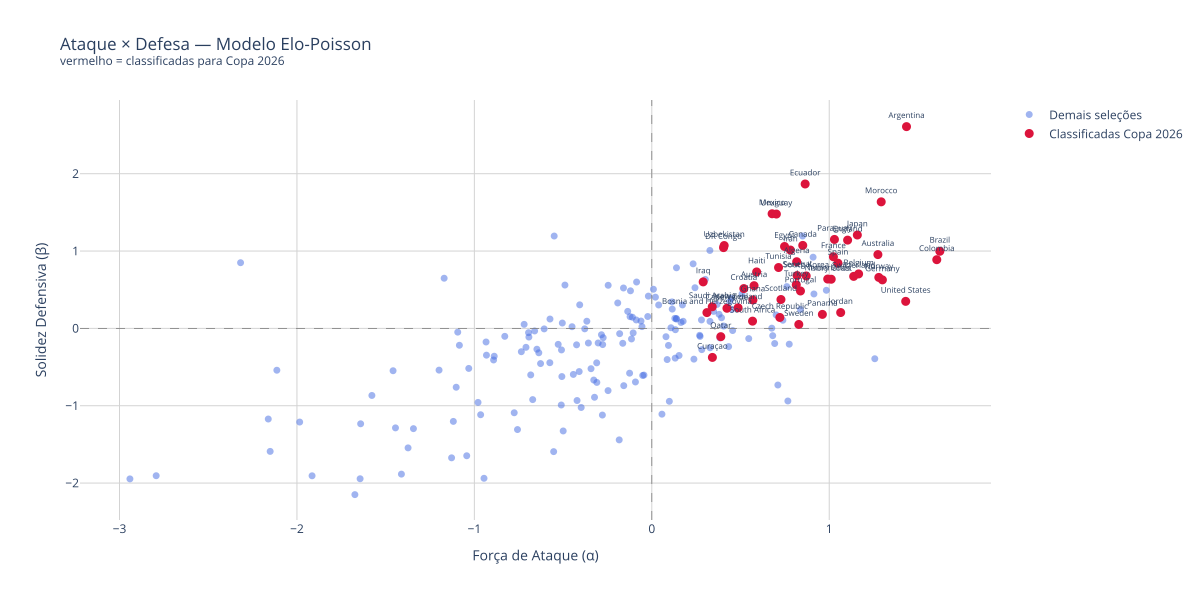

In [6]:
cup_teams = {t for grp in GROUPS.values() for t in grp}
others = params[~params.index.isin(cup_teams)]
cup = params[params.index.isin(cup_teams)]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=others["alpha"],
        y=others["beta"],
        mode="markers",
        marker={"color": "royalblue", "size": 7, "opacity": 0.5},
        name="Demais seleções",
    )
)
fig.add_trace(
    go.Scatter(
        x=cup["alpha"],
        y=cup["beta"],
        mode="markers+text",
        marker={"color": "crimson", "size": 9},
        text=cup.index,
        textposition="top center",
        textfont={"size": 8},
        name="Classificadas Copa 2026",
    )
)
fig.add_hline(y=0, line_width=0.8, line_dash="dash", line_color="gray")
fig.add_vline(x=0, line_width=0.8, line_dash="dash", line_color="gray")
fig.update_layout(
    title=(
        "Ataque × Defesa — Modelo Elo-Poisson"
        "<br><sup>vermelho = classificadas para Copa 2026</sup>"
    ),
    xaxis_title="Força de Ataque (α)",
    yaxis_title="Solidez Defensiva (β)",
    height=600,
    width=1200,
    plot_bgcolor="white",
    paper_bgcolor="white",
)
fig.update_xaxes(showgrid=True, gridcolor="lightgrey", zeroline=False)
fig.update_yaxes(showgrid=True, gridcolor="lightgrey", zeroline=False)
fig.write_image("../data/outputs/elo_poisson_ataque_defesa.png", scale=2)
fig.show(renderer="svg")

## 5. Predição e probabilidades para partidas específicas

Com os parâmetros finais, calculamos as taxas esperadas de gols $\lambda_A$ e $\lambda_B$ para qualquer confronto e derivamos a distribuição conjunta de placares via produto de Poisson. As probabilidades de vitória, empate e derrota são obtidas somando as regiões correspondentes da matriz de placares.

In [7]:
MAX_GOALS = 4


def match_probs(model, home, away):
    lam_h, lam_a = model.expected_goals(home, away)
    goals = np.arange(0, MAX_GOALS + 1)
    mat = np.outer(sp_poisson.pmf(goals, lam_h), sp_poisson.pmf(goals, lam_a))
    return {
        "home_team": home,
        "away_team": away,
        "λ_home": round(lam_h, 3),
        "λ_away": round(lam_a, 3),
        "P(home win)": round(float(np.tril(mat, -1).sum()), 3),
        "P(draw)": round(float(np.trace(mat)), 3),
        "P(away win)": round(float(np.triu(mat, 1).sum()), 3),
    }


matchups = [
    ("Brazil", "Morocco"),
    ("Argentina", "Austria"),
    ("France", "Senegal"),
    ("Spain", "Uruguay"),
]

rows = [
    match_probs(model, h, a)
    for h, a in matchups
    if h in model.alpha and a in model.alpha
]
pd.DataFrame(rows)

,home_team,away_team,λ_home,λ_away,P(home win),P(draw),P(away win)
0,Brazil,Morocco,0.987,1.344,0.271,0.276,0.437
1,Argentina,Austria,2.419,0.131,0.784,0.105,0.013
2,France,Senegal,1.406,0.899,0.473,0.272,0.238
3,Spain,Uruguay,0.651,0.868,0.256,0.361,0.381


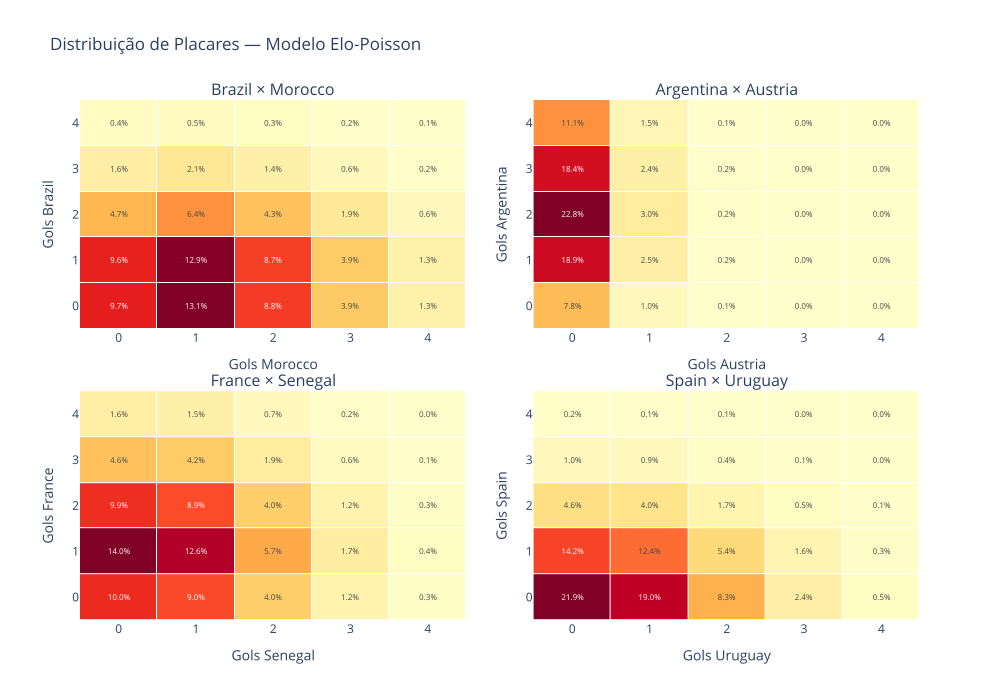

In [8]:
valid = [(h, a) for h, a in matchups if h in model.alpha and a in model.alpha]
goals_labels = list(range(MAX_GOALS + 1))

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f"{h} × {a}" for h, a in valid],
    vertical_spacing=0.12,
    horizontal_spacing=0.08,
)

for (home, away), (r, c) in zip(valid, [(1, 1), (1, 2), (2, 1), (2, 2)], strict=False):
    lam_h, lam_a = model.expected_goals(home, away)
    goals = np.arange(0, MAX_GOALS + 1)
    M = np.outer(sp_poisson.pmf(goals, lam_h), sp_poisson.pmf(goals, lam_a)) * 100
    text = [[f"{M[i,j]:.1f}%" for j in goals_labels] for i in goals_labels]
    fig.add_trace(
        go.Heatmap(
            z=M,
            x=goals_labels,
            y=goals_labels,
            text=text,
            texttemplate="%{text}",
            textfont={"size": 8},
            colorscale="YlOrRd",
            showscale=False,
            xgap=1,
            ygap=1,
        ),
        row=r,
        col=c,
    )
    fig.update_xaxes(title_text=f"Gols {away}", row=r, col=c, tickvals=goals_labels)
    fig.update_yaxes(title_text=f"Gols {home}", row=r, col=c, tickvals=goals_labels)

fig.update_layout(
    title_text="Distribuição de Placares — Modelo Elo-Poisson",
    height=700,
    width=1000,
    plot_bgcolor="white",
    paper_bgcolor="white",
)
fig.write_image("../data/outputs/elo_poisson_heatmap_placares.png", scale=2)
fig.show(renderer="svg")

## 6. Evolução temporal dos parâmetros

Reprocessamos o dataset em ordem cronológica com um modelo separado para registrar o estado de α, β e α+β de cada seleção antes de cada atualização. Os pesos por competição são usados também nesse passo, garantindo consistência com o modelo treinado na seção 3.

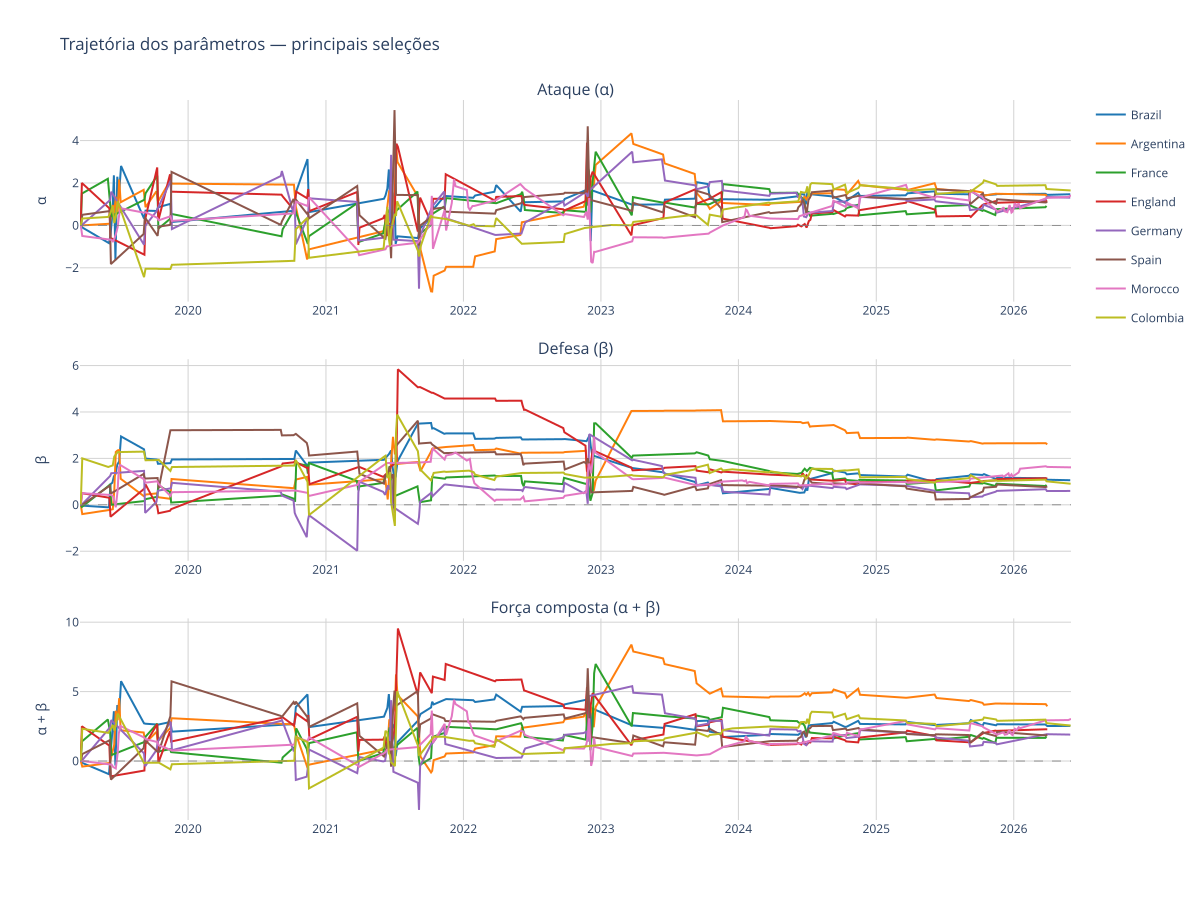

In [9]:
TRACK_TEAMS = [
    "Brazil",
    "Argentina",
    "France",
    "England",
    "Germany",
    "Spain",
    "Morocco",
    "Colombia",
]
TRACK_TEAMS = [t for t in TRACK_TEAMS if t in teams]

history = {
    t: {
        "alpha": [],
        "beta": [],
        "strength": [],
        "date": [],
        "opponent": [],
        "score": [],
        "is_home": [],
    }
    for t in TRACK_TEAMS
}
tracker = EloPoissonModel(teams, eta=ETA, eta_phases=ETA_PHASES, grad_clip=GRAD_CLIP)

has_weight = "game_weight" in df.columns
for row in df.itertuples(index=False):
    home, away = row.home_team, row.away_team
    if home not in tracker.alpha or away not in tracker.alpha:
        continue
    for t, opp, is_home in ((home, away, True), (away, home, False)):
        if t in history:
            a = tracker.alpha[t]
            b = tracker.beta[t]
            history[t]["alpha"].append(a)
            history[t]["beta"].append(b)
            history[t]["strength"].append(a + b)
            # convert to Python datetime so kaleido/orjson can serialize
            history[t]["date"].append(pd.Timestamp(row.date).to_pydatetime())
            history[t]["opponent"].append(opp)
            history[t]["is_home"].append(is_home)
            if is_home:
                history[t]["score"].append(
                    f"{int(row.home_score)}-{int(row.away_score)}"
                )
            else:
                history[t]["score"].append(
                    f"{int(row.away_score)}-{int(row.home_score)}"
                )
    w = row.game_weight if has_weight else 1.0
    tracker.update(home, away, int(row.home_score), int(row.away_score), weight=w)


colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#bcbd22",
]
fig = make_subplots(
    rows=3,
    cols=1,
    subplot_titles=["Ataque (α)", "Defesa (β)", "Força composta (α + β)"],
    vertical_spacing=0.08,
)
for i, t in enumerate(TRACK_TEAMS):
    h = history[t]
    if not h["date"]:
        continue
    color = colors[i % len(colors)]
    common = {"name": t, "line": {"color": color}, "legendgroup": t}
    fig.add_trace(
        go.Scatter(x=h["date"], y=h["alpha"], mode="lines", **common), row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=h["date"], y=h["beta"], mode="lines", **common, showlegend=False),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=h["date"], y=h["strength"], mode="lines", **common, showlegend=False
        ),
        row=3,
        col=1,
    )

for r in (1, 2, 3):
    fig.add_hline(
        y=0, line_width=0.8, line_dash="dash", line_color="gray", row=r, col=1
    )

fig.update_yaxes(
    title_text="α", row=1, col=1, showgrid=True, gridcolor="lightgrey", zeroline=False
)
fig.update_yaxes(
    title_text="β", row=2, col=1, showgrid=True, gridcolor="lightgrey", zeroline=False
)
fig.update_yaxes(
    title_text="α + β",
    row=3,
    col=1,
    showgrid=True,
    gridcolor="lightgrey",
    zeroline=False,
)
fig.update_xaxes(showgrid=True, gridcolor="lightgrey", zeroline=False)
fig.update_layout(
    title_text="Trajetória dos parâmetros — principais seleções",
    height=900,
    width=1200,
    plot_bgcolor="white",
    paper_bgcolor="white",
)
fig.write_image("../data/outputs/elo_poisson_trajetoria_parametros.png", scale=2)
fig.show(renderer="svg")

## 7. Ranking final das seleções classificadas para a Copa 2026

Ordenação das 48 seleções pela força composta α + β, que combina capacidade ofensiva e solidez defensiva aprendidas pelo modelo ao longo do período de treinamento.

In [10]:
group_of = {t: g for g, ts in GROUPS.items() for t in ts}
cup_teams = {t for grp in GROUPS.values() for t in grp}

ranking = (
    params.loc[params.index.isin(cup_teams)]
    .copy()
    .sort_values("strength", ascending=False)
    .reset_index()
)
ranking.insert(0, "pos", range(1, len(ranking) + 1))
ranking["group"] = ranking["team"].map(group_of)
ranking[["alpha", "beta", "strength"]] = ranking[["alpha", "beta", "strength"]].round(4)

print(f"Ranking Elo-Poisson — {len(ranking)} seleções classificadas")
ranking[["pos", "team", "group", "alpha", "beta", "strength"]].head(10)

Ranking Elo-Poisson — 48 seleções classificadas


,pos,team,group,alpha,beta,strength
0,1,Argentina,J,1.4355,2.6089,4.0443
1,2,Morocco,C,1.2929,1.6364,2.9293
2,3,Ecuador,E,0.8643,1.8671,2.7314
3,4,Brazil,C,1.6233,0.9970,2.6202
4,5,Colombia,K,1.6061,0.8884,2.4945
5,6,Japan,F,1.1584,1.2076,2.3660
6,7,England,L,1.1035,1.1413,2.2448
7,8,Australia,D,1.2742,0.9542,2.2284
8,9,Uruguay,H,0.7021,1.4783,2.1805
9,10,Paraguay,D,1.0293,1.1503,2.1796


## 8. Jogos de maior impacto no Elo

Para cada seleção rastreada, calculamos a variação Δ(α + β) entre jogos consecutivos. O impacto de um jogo é a diferença no parâmetro de força *após* a atualização em relação ao estado anterior.

In [11]:
TOP_N = 5  # jogos de maior impacto positivo e negativo por seleção

impact_rows = []
for t in TRACK_TEAMS:
    h = history[t]
    strengths = h["strength"]
    if len(strengths) < 2:
        continue
    deltas = np.diff(strengths)
    for i, delta in enumerate(deltas):
        impact_rows.append(
            {
                "team": t,
                "date": h["date"][i],
                "opponent": h["opponent"][i],
                "score": h["score"][i],
                "is_home": h["is_home"][i],
                "delta_strength": delta,
                "delta_alpha": h["alpha"][i + 1] - h["alpha"][i],
                "delta_beta": h["beta"][i + 1] - h["beta"][i],
            }
        )

impact_df = pd.DataFrame(impact_rows)
impact_df["match"] = impact_df.apply(
    lambda r: f"{r['team']} × {r['opponent']}"
    if r["is_home"]
    else f"{r['opponent']} × {r['team']}",
    axis=1,
)

cols = ["team", "date", "match", "score", "delta_alpha", "delta_beta", "delta_strength"]
rename = {"delta_alpha": "Δα", "delta_beta": "Δβ", "delta_strength": "Δ(α+β)"}

print("=== Top jogos de maior impacto positivo (Δ força) ===")
top_pos = pd.concat(
    [g.nlargest(TOP_N, "delta_strength") for _, g in impact_df.groupby("team")]
).reset_index(drop=True)
display(top_pos[cols].rename(columns=rename).round(4))

print("\n=== Top jogos de maior impacto negativo (Δ força) ===")
top_neg = pd.concat(
    [g.nsmallest(TOP_N, "delta_strength") for _, g in impact_df.groupby("team")]
).reset_index(drop=True)
display(top_neg[cols].rename(columns=rename).round(4))

=== Top jogos de maior impacto positivo (Δ força) ===


/tmp/ipykernel_30147/621933027.py:39: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(top_pos[cols].rename(columns=rename).round(4))


,team,date,match,score,Δα,Δβ,Δ(α+β)
0,Argentina,2022-12-18,Argentina × France,3-3,1.4908,3.0000,4.4908
1,Argentina,2019-06-19,Argentina × Paraguay,1-1,0.7713,1.6631,2.4345
2,Argentina,2021-07-03,Argentina × Ecuador,3-0,2.0752,0.2868,2.3620
3,Argentina,2021-06-14,Argentina × Chile,1-1,0.6036,1.0644,1.6680
4,Argentina,2019-06-28,Venezuela × Argentina,2-0,1.5717,0.0138,1.5855
5,Brazil,2019-06-22,Brazil × Peru,5-0,3.9339,0.4199,4.3538
6,Brazil,2019-07-02,Brazil × Argentina,2-0,1.2380,1.0753,2.3132
7,Brazil,2019-06-14,Brazil × Bolivia,3-0,1.8066,0.2721,2.0786
8,Brazil,2022-12-05,Brazil × South Korea,4-1,2.3896,-0.3963,1.9933
9,Brazil,2021-07-10,Brazil × Argentina,0-1,-0.0819,1.6188,1.5369



=== Top jogos de maior impacto negativo (Δ força) ===


/tmp/ipykernel_30147/621933027.py:45: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(top_neg[cols].rename(columns=rename).round(4))


,team,date,match,score,Δα,Δβ,Δ(α+β)
0,Argentina,2021-09-02,Venezuela × Argentina,3-1,-2.5000,-0.3936,-2.8936
1,Argentina,2020-10-13,Bolivia × Argentina,2-1,-2.5000,0.1130,-2.3870
2,Argentina,2019-07-02,Brazil × Argentina,0-2,-1.0753,-1.2380,-2.3132
3,Argentina,2021-07-10,Brazil × Argentina,1-0,-1.6188,0.0819,-1.5369
4,Argentina,2021-07-06,Argentina × Colombia,1-1,-0.7989,-0.6929,-1.4918
5,Brazil,2019-06-18,Brazil × Venezuela,0-0,-4.0000,0.0873,-3.9127
6,Brazil,2019-07-07,Brazil × Peru,3-1,-2.4804,-0.5560,-3.0365
7,Brazil,2021-06-17,Brazil × Peru,4-0,-2.8492,0.1614,-2.6878
8,Brazil,2022-12-02,Cameroon × Brazil,0-1,-1.9552,-0.4704,-2.4256
9,Brazil,2020-11-13,Brazil × Venezuela,1-0,-2.5000,0.1454,-2.3546
